# Preprocess for colab laboratory

In [ ]:
# Upload files into colab environment 
# Files will be in /content/uploaded_file

from google.colab import files
uploaded = files.upload()


In [3]:
# derive csv files from the excel file
import pandas as pd

filepath = "어린이코호트 임상데이터.xlsx"

df1 = pd.read_excel(filepath, sheet_name=0)
df2 = pd.read_excel(filepath, sheet_name=1)

print(df1.head())
print(df2.head())

   환자명 성별  나이  ALB(S)  ALT  AST  Iron(S)  Free T4   T3    TSH  ...   WBC  RBC  \
0    1  여   6     4.7    9   27       99     1.27  135  1.865  ...  6.43  4.4   
1    2  여   7     4.8   40   32      147     1.45  158  1.344  ...  6.37  4.3   
2    3  여   6     4.8    9   28      115     1.34  115  2.405  ...  5.62  4.4   
3    4  여   7     4.7   16   29      109     1.20  132  1.223  ...  6.32  4.3   
4    5  여   7     4.7    9   27      116     1.21  152  2.346  ...  4.53  4.0   

  Hemoglobin  Hematocrit  Platelet  FSH      E2  Testosterone     LH 고위험군  
0       13.2        38.7       317  2.6  < 5.00           NaN  < 0.3    0  
1       12.7        36.5       368  1.7       5           NaN    0.3    1  
2       12.0        37.8       283  1.6       5           NaN    0.3    1  
3       12.5        36.3       336  1.2  < 5.00           NaN  < 0.3    0  
4       11.4        33.7       277  2.1       5           NaN    0.3    1  

[5 rows x 24 columns]
   환자명 성별  나이  ALB(S)  ALT  AST  I

In [4]:
print(df1.describe())
print(df1.shape)

             환자명          나이      ALB(S)         ALT         AST     Iron(S)  \
count  313.00000  313.000000  313.000000  313.000000  313.000000  313.000000   
mean   157.00000    7.805112    4.789457   13.290735   25.763578   94.290735   
std     90.49954    1.449040    0.227551    6.169752    7.287262   31.274454   
min      1.00000    6.000000    3.500000    3.000000   16.000000   28.000000   
25%     79.00000    7.000000    4.700000   10.000000   22.000000   73.000000   
50%    157.00000    7.000000    4.800000   12.000000   25.000000   93.000000   
75%    235.00000    9.000000    4.900000   15.000000   28.000000  113.000000   
max    313.00000   10.000000    5.700000   47.000000  127.000000  200.000000   

          Free T4          T3         TSH  T.Cholestero       HbA1c  \
count  313.000000  313.000000  313.000000    313.000000  313.000000   
mean     1.327316  159.472843    2.508987    175.031949    5.351438   
std      0.191620   25.044065    1.301915     28.779649    0.25634

In [5]:
# Clean the data by removing rows with missing values
df1_cleaned = df1.drop(columns=["환자명","성별","Testosterone"]).dropna()
df2_cleaned = df2.drop(columns=["환자명","성별"]).dropna()

In [6]:
print(df1_cleaned.head())
print(df2_cleaned.head())

   나이  ALB(S)  ALT  AST  Iron(S)  Free T4   T3    TSH  T.Cholestero  \
0   6     4.7    9   27       99     1.27  135  1.865           186   
1   7     4.8   40   32      147     1.45  158  1.344           194   
2   6     4.8    9   28      115     1.34  115  2.405           160   
3   7     4.7   16   29      109     1.20  132  1.223           184   
4   7     4.7    9   27      116     1.21  152  2.346           197   

  Glu-FBS(S)  ... HbA1c   WBC  RBC  Hemoglobin  Hematocrit  Platelet  FSH  \
0        공복X  ...   5.5  6.43  4.4        13.2        38.7       317  2.6   
1         86  ...   5.3  6.37  4.3        12.7        36.5       368  1.7   
2        공복X  ...   5.4  5.62  4.4        12.0        37.8       283  1.6   
3        공복X  ...   5.2  6.32  4.3        12.5        36.3       336  1.2   
4        공복X  ...   5.5  4.53  4.0        11.4        33.7       277  2.1   

       E2     LH 고위험군  
0  < 5.00  < 0.3    0  
1       5    0.3    1  
2       5    0.3    1  
3  < 5.00  < 0

In [7]:
print(df1.shape, df1_cleaned.shape) # for female
print(df2.shape, df2_cleaned.shape) # for male

(313, 24) (313, 21)
(347, 24) (346, 22)


## Replace data "공복X" in the column "Glu-FBS(S)" and "Insulin"with mean_value of the column

In [8]:
# Replace "공복x" with mean value in "Glu-FBS(S)" column
# First, convert to numeric (non-numeric strings like "공복x" become NaN)
df1_replaced = df1_cleaned.copy()
df1_replaced["Glu-FBS(S)"] = pd.to_numeric(df1_replaced["Glu-FBS(S)"], errors='coerce')
df1_replaced["Insulin"] = pd.to_numeric(df1_replaced["Insulin"], errors='coerce')

# Calculate mean of numeric values (ignores NaN)
mean_glu = df1_replaced["Glu-FBS(S)"].mean().round(3)
mean_insulin = df1_replaced["Insulin"].mean().round(3)
print(f"Mean Glu-FBS(S): {mean_glu}")
print(f"Mean Insulin: {mean_insulin}")
# Replace NaN (which came from "공복x") with the mean
df1_replaced["Glu-FBS(S)"] = df1_replaced["Glu-FBS(S)"].fillna(mean_glu)
df1_replaced["Insulin"] = df1_replaced["Insulin"].fillna(mean_insulin)

print(f"Mean Glu-FBS(S): {mean_glu}")
print(f"Mean Insulin: {mean_insulin}")
print(df1_replaced.head())
print(f"Original shape: {df1_cleaned.shape}, After replacement: {df1_replaced.shape}")

Mean Glu-FBS(S): 84.429
Mean Insulin: 7.435
Mean Glu-FBS(S): 84.429
Mean Insulin: 7.435
   나이  ALB(S)  ALT  AST  Iron(S)  Free T4   T3    TSH  T.Cholestero  \
0   6     4.7    9   27       99     1.27  135  1.865           186   
1   7     4.8   40   32      147     1.45  158  1.344           194   
2   6     4.8    9   28      115     1.34  115  2.405           160   
3   7     4.7   16   29      109     1.20  132  1.223           184   
4   7     4.7    9   27      116     1.21  152  2.346           197   

   Glu-FBS(S)  ...  HbA1c   WBC  RBC  Hemoglobin  Hematocrit  Platelet  FSH  \
0      84.429  ...    5.5  6.43  4.4        13.2        38.7       317  2.6   
1      86.000  ...    5.3  6.37  4.3        12.7        36.5       368  1.7   
2      84.429  ...    5.4  5.62  4.4        12.0        37.8       283  1.6   
3      84.429  ...    5.2  6.32  4.3        12.5        36.3       336  1.2   
4      84.429  ...    5.5  4.53  4.0        11.4        33.7       277  2.1   

       E2 

In [9]:
# Replace "공복x" with mean value in "Glu-FBS(S)" column
# First, convert to numeric (non-numeric strings like "공복x" become NaN)
df1_replaced_1 = df1_replaced.copy()
df1_replaced_1["FSH"] = pd.to_numeric(df1_replaced_1["FSH"], errors='coerce')
df1_replaced_1["E2"] = pd.to_numeric(df1_replaced_1["E2"], errors='coerce')
df1_replaced_1["LH"] = pd.to_numeric(df1_replaced_1["LH"], errors='coerce')
# Calculate mean of numeric values (ignores NaN)
FSH_val = 0.20
E2_val = 4.00 # Assuming 4.00 is the chosen value for E2 
LH_val = 0.15 # Assuming 0.15 is the chosen value for LH
# Replace NaN (which came from "공복x") with the mean
df1_replaced_1["FSH"] = df1_replaced_1["FSH"].fillna(FSH_val)
df1_replaced_1["E2"] = df1_replaced_1["E2"].fillna(E2_val)
df1_replaced_1["LH"] = df1_replaced_1["LH"].fillna(LH_val)

print(df1_replaced_1.head())
print(f"Original shape: {df1_cleaned.shape}, After replacement: {df1_replaced_1.shape}")
df1_replaced_1.to_csv("female_cohort_preprocessed.csv", index=False)

   나이  ALB(S)  ALT  AST  Iron(S)  Free T4   T3    TSH  T.Cholestero  \
0   6     4.7    9   27       99     1.27  135  1.865           186   
1   7     4.8   40   32      147     1.45  158  1.344           194   
2   6     4.8    9   28      115     1.34  115  2.405           160   
3   7     4.7   16   29      109     1.20  132  1.223           184   
4   7     4.7    9   27      116     1.21  152  2.346           197   

   Glu-FBS(S)  ...  HbA1c   WBC  RBC  Hemoglobin  Hematocrit  Platelet  FSH  \
0      84.429  ...    5.5  6.43  4.4        13.2        38.7       317  2.6   
1      86.000  ...    5.3  6.37  4.3        12.7        36.5       368  1.7   
2      84.429  ...    5.4  5.62  4.4        12.0        37.8       283  1.6   
3      84.429  ...    5.2  6.32  4.3        12.5        36.3       336  1.2   
4      84.429  ...    5.5  4.53  4.0        11.4        33.7       277  2.1   

    E2    LH  고위험군  
0  4.0  0.15     0  
1  5.0  0.30     1  
2  5.0  0.30     1  
3  4.0  0.15  

##  Cleanup the dataset for df2

In [10]:
# Replace "공복x" with mean value in "Glu-FBS(S)" column
# First, convert to numeric (non-numeric strings like "공복x" become NaN)
df2_replaced = df2_cleaned.copy()
df2_replaced["Glu-FBS(S)"] = pd.to_numeric(df2_replaced["Glu-FBS(S)"], errors='coerce')
df2_replaced["Insulin"] = pd.to_numeric(df2_replaced["Insulin"], errors='coerce')

# Calculate mean of numeric values (ignores NaN)
mean_glu = df2_replaced["Glu-FBS(S)"].mean().round(3)
mean_insulin = df2_replaced["Insulin"].mean().round(3)
print(f"Mean Glu-FBS(S): {mean_glu}")
print(f"Mean Insulin: {mean_insulin}")
# Replace NaN (which came from "공복x") with the mean
df2_replaced["Glu-FBS(S)"] = df2_replaced["Glu-FBS(S)"].fillna(mean_glu)
df2_replaced["Insulin"] = df2_replaced["Insulin"].fillna(mean_insulin)

print(f"Mean Glu-FBS(S): {mean_glu}")
print(f"Mean Insulin: {mean_insulin}")
print(df2_replaced.head())
print(f"Original shape: {df2_cleaned.shape}, After replacement: {df2_replaced.shape}")

Mean Glu-FBS(S): 87.106
Mean Insulin: 9.268
Mean Glu-FBS(S): 87.106
Mean Insulin: 9.268
   나이  ALB(S)  ALT  AST  Iron(S)  Free T4   T3   TSH  T.Cholestero  \
0  10     4.7    9   23      103     1.29  184  2.60           168   
1  10     4.7   83   46       67     1.43  166  8.69           188   
2   9     5.1   15   26       98     1.43  166  2.76           220   
3   9     4.8   20   30       59     1.34  214  2.99           174   
4   9     4.6   11   24      120     1.10  183  1.60           168   

   Glu-FBS(S)  ...   WBC  RBC  Hemoglobin  Hematocrit  Platelet  FSH      E2  \
0      87.106  ...  5.01  4.5        13.7        41.5       348  1.4  < 5.00   
1      78.000  ...  9.11  5.2        14.6        43.3       484    1  < 5.00   
2      87.106  ...  2.47  4.9        14.6        42.2       222  1.9  < 5.00   
3      81.000  ...  8.60  5.2        15.0        44.5       310  2.7  < 5.00   
4      84.000  ...  7.68  4.9        14.6        43.8       345  3.4  < 5.00   

  Testoste

In [11]:
# Replace "공복x" with mean value in "Glu-FBS(S)" column
# First, convert to numeric (non-numeric strings like "공복x" become NaN)
df2_replaced_1 = df1_replaced.copy()
df2_replaced_1["FSH"] = pd.to_numeric(df2_replaced_1["FSH"], errors='coerce')
df2_replaced_1["E2"] = pd.to_numeric(df2_replaced_1["E2"], errors='coerce')
df2_replaced_1["LH"] = pd.to_numeric(df2_replaced_1["LH"], errors='coerce')
# Calculate mean of numeric values (ignores NaN)
FSH_val = 0.20
E2_val = 4.00 # Assuming 4.00 is the chosen value for E2 
LH_val = 0.15 # Assuming 0.15 is the chosen value for LH
# Replace NaN (which came from "공복x") with the mean
df2_replaced_1["FSH"] = df2_replaced_1["FSH"].fillna(FSH_val)
df2_replaced_1["E2"] = df2_replaced_1["E2"].fillna(E2_val)
df2_replaced_1["LH"] = df2_replaced_1["LH"].fillna(LH_val)

print(df2_replaced_1.head())
print(f"Original shape: {df1_cleaned.shape}, After replacement: {df2_replaced_1.shape}")
df2_replaced_1.to_csv("male_cohort_preprocessed.csv", index=False)

   나이  ALB(S)  ALT  AST  Iron(S)  Free T4   T3    TSH  T.Cholestero  \
0   6     4.7    9   27       99     1.27  135  1.865           186   
1   7     4.8   40   32      147     1.45  158  1.344           194   
2   6     4.8    9   28      115     1.34  115  2.405           160   
3   7     4.7   16   29      109     1.20  132  1.223           184   
4   7     4.7    9   27      116     1.21  152  2.346           197   

   Glu-FBS(S)  ...  HbA1c   WBC  RBC  Hemoglobin  Hematocrit  Platelet  FSH  \
0      84.429  ...    5.5  6.43  4.4        13.2        38.7       317  2.6   
1      86.000  ...    5.3  6.37  4.3        12.7        36.5       368  1.7   
2      84.429  ...    5.4  5.62  4.4        12.0        37.8       283  1.6   
3      84.429  ...    5.2  6.32  4.3        12.5        36.3       336  1.2   
4      84.429  ...    5.5  4.53  4.0        11.4        33.7       277  2.1   

    E2    LH  고위험군  
0  4.0  0.15     0  
1  5.0  0.30     1  
2  5.0  0.30     1  
3  4.0  0.15  

## Data are preprocessed for training with model

## Data visualization Histogram

In [12]:
# identify the column names in the preprocessed dataframes
print(df1_replaced_1.columns)

Index(['나이', 'ALB(S)', 'ALT', 'AST', 'Iron(S)', 'Free T4', 'T3', 'TSH',
       'T.Cholestero', 'Glu-FBS(S)', 'Insulin', 'HbA1c', 'WBC', 'RBC',
       'Hemoglobin', 'Hematocrit', 'Platelet', 'FSH', 'E2', 'LH', '고위험군'],
      dtype='object')


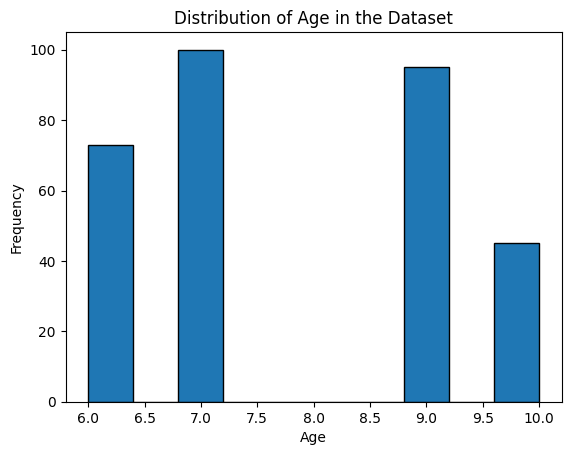

In [13]:
# display the Histogram for "나이" for women 
import matplotlib.pyplot as plt
plt.hist(df1_replaced_1["나이"], bins=10, edgecolor='black')
plt.title("Distribution of Age in the Dataset")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()
plt.close()

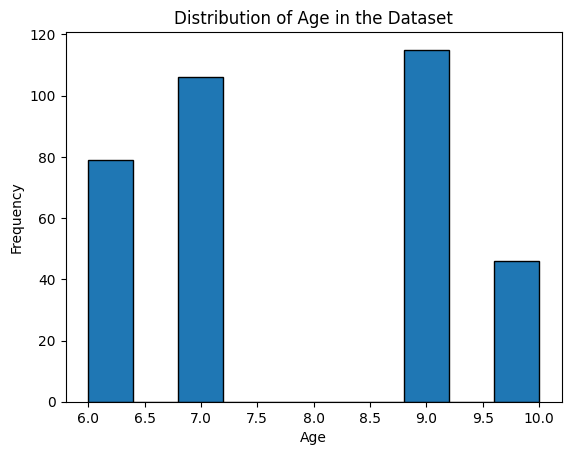

In [14]:
# display the Histogram for "나이" for man
import matplotlib.pyplot as plt
plt.hist(df2_replaced["나이"], bins=10, edgecolor='black')
plt.title("Distribution of Age in the Dataset")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()
plt.close()

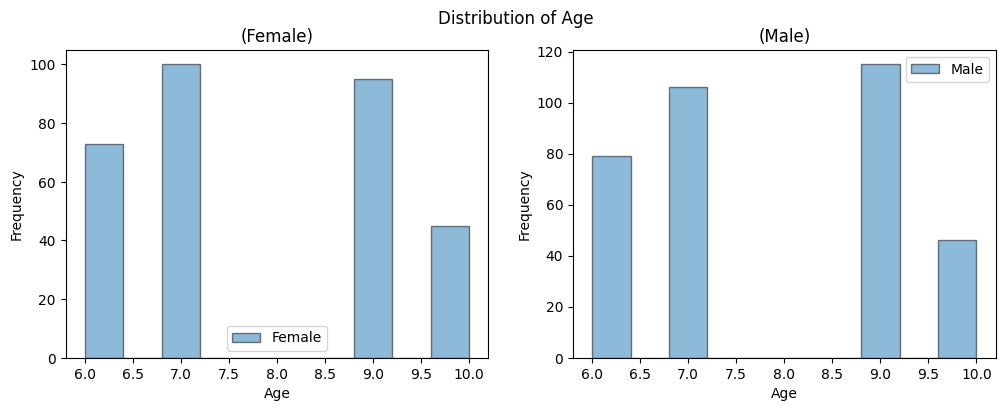

In [15]:
# combine the two histograms into one plot using subplot for comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df1_replaced_1["나이"], bins=10, edgecolor='black', alpha=0.5, label='Female')
axes[0].set_title("(Female)")
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Frequency")
axes[0].legend()

axes[1].hist(df2_replaced["나이"], bins=10, edgecolor='black', alpha=0.5, label='Male')
axes[1].set_title("(Male)")
axes[1].set_xlabel("Age")
axes[1].set_ylabel("Frequency")
axes[1].legend()

# Increase horizontal space between subplots
fig.subplots_adjust(wspace=0.2)
plt.suptitle("Distribution of Age")
plt.show()
plt.close()

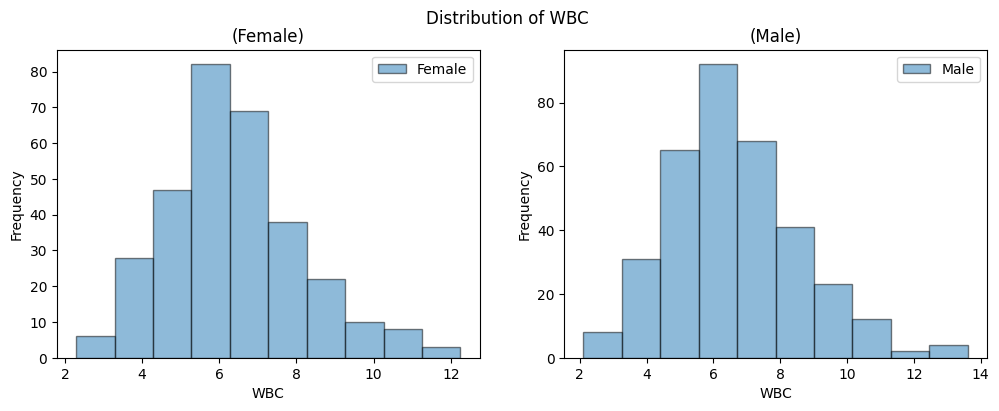

In [16]:
# combine the two histograms into one plot using subplot for comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df1_replaced_1["WBC"], bins=10, edgecolor='black', alpha=0.5, label='Female')
axes[0].set_title("(Female)")
axes[0].set_xlabel("WBC")
axes[0].set_ylabel("Frequency")
axes[0].legend()

axes[1].hist(df2_replaced["WBC"], bins=10, edgecolor='black', alpha=0.5, label='Male')
axes[1].set_title("(Male)")
axes[1].set_xlabel("WBC")
axes[1].set_ylabel("Frequency")
axes[1].legend()

# Increase horizontal space between subplots
fig.subplots_adjust(wspace=0.2)
plt.suptitle("Distribution of WBC")
plt.show()
plt.close()